In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
networks = ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"]

effects = pd.DataFrame({
    "network": networks,
    "acute_mean": [-0.72, 0.50, 0.30, 0.38, 0.18, 0.06],
    "postacute_mean": [-0.36, 0.22, 0.05, 0.21, 0.03, 0.04]
})

effects

,network,acute_mean,postacute_mean
0,DMN,-0.72,-0.36
1,Salience,0.50,0.22
2,FPN,0.30,0.05
3,Limbic,0.38,0.21
4,Visual,0.18,0.03
5,Somatomotor,0.06,0.04


In [4]:
boot_rows = []

for _, row in effects.iterrows():
    samples = np.random.normal(row["acute_mean"], 0.12, 1000)
    ci_low = np.percentile(samples, 2.5)
    ci_high = np.percentile(samples, 97.5)
    boot_rows.append([row["network"], samples.mean(), ci_low, ci_high])

boot = pd.DataFrame(
    boot_rows,
    columns=["network", "boot_mean", "ci_low", "ci_high"]
)

boot

,network,boot_mean,ci_low,ci_high
0,DMN,-0.717680,-0.940984,-0.490704
1,Salience,0.508500,0.275990,0.747383
2,FPN,0.300700,0.070507,0.534524
3,Limbic,0.377754,0.136831,0.614449
4,Visual,0.174087,-0.070864,0.387213
5,Somatomotor,0.054391,-0.180093,0.304324


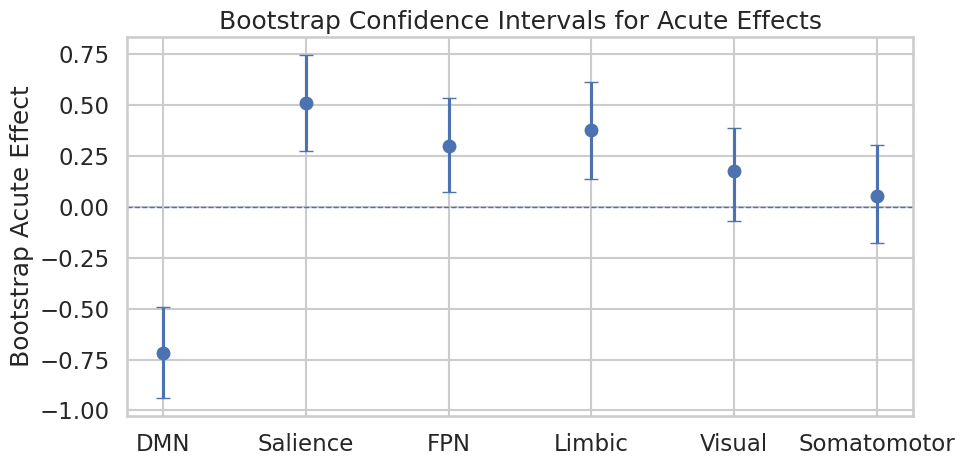

In [5]:
plt.figure(figsize=(10,5))

plt.errorbar(
    x=boot["network"],
    y=boot["boot_mean"],
    yerr=[
        boot["boot_mean"] - boot["ci_low"],
        boot["ci_high"] - boot["boot_mean"]
    ],
    fmt="o",
    capsize=5
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Bootstrap Acute Effect")
plt.title("Bootstrap Confidence Intervals for Acute Effects")
plt.tight_layout()
plt.savefig("figures/05_bootstrap_ci.png", dpi=300)
plt.show()

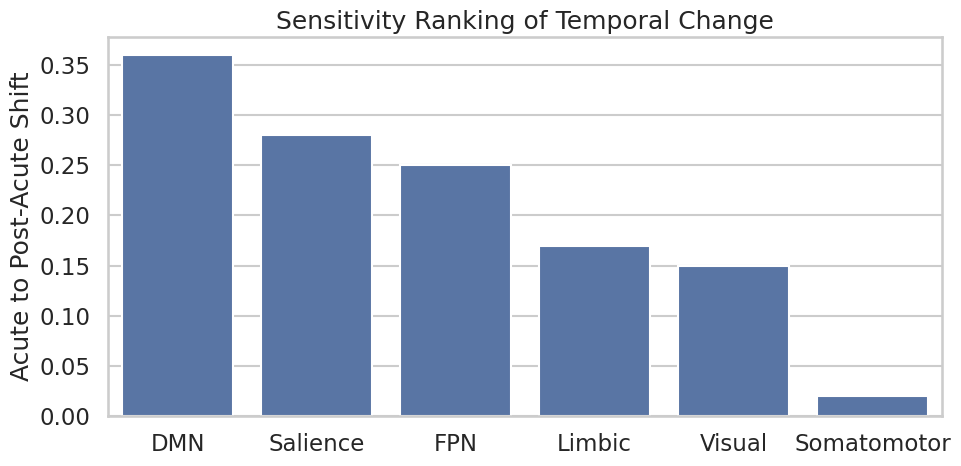

In [6]:
effects["abs_change"] = np.abs(effects["acute_mean"] - effects["postacute_mean"])
effects["rank"] = effects["abs_change"].rank(ascending=False).astype(int)

plt.figure(figsize=(10,5))

sns.barplot(
    data=effects.sort_values("abs_change", ascending=False),
    x="network",
    y="abs_change"
)

plt.xlabel("")
plt.ylabel("Acute to Post-Acute Shift")
plt.title("Sensitivity Ranking of Temporal Change")
plt.tight_layout()
plt.savefig("figures/05_sensitivity_ranking.png", dpi=300)
plt.show()

In [7]:
boot.to_csv("outputs/05_bootstrap_summary.csv", index=False)
effects.to_csv("outputs/05_temporal_sensitivity.csv", index=False)

repro = effects[["network", "rank"]].sort_values("rank")
repro

,network,rank
0,DMN,1
1,Salience,2
2,FPN,3
3,Limbic,4
4,Visual,5
5,Somatomotor,6
